# Superstore Sales Performance Analysis

**Analisis Data Analyst Portfolio — dengan Python (pandas, numpy, matplotlib, seaborn)**

Notebook ini menganalisis data penjualan retail *Sample Superstore* (AS, Januari 2015 – Desember 2018) untuk menjawab pertanyaan bisnis: **produk, kategori, dan pelanggan mana yang benar-benar mendorong profit, dan di mana diskon justru menggerus keuntungan?**

Notebook ini dibuat sebagai pengganti Power BI — semua analisis, agregasi, forecasting, dan segmentasi pelanggan dilakukan murni dengan Python, lalu divisualisasikan langsung di sini dan pada dashboard interaktif (`dashboard/dashboard.html`).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

plt.rcParams['figure.facecolor'] = 'white'
sns.set_style('whitegrid')

NAVY, BLUE, TEAL, AMBER, RED, GREY = '#1F3864', '#2E75B6', '#0E9594', '#E2703A', '#C00000', '#666666'

df = pd.read_csv('../data/Superstore_Orders_Clean.csv', parse_dates=['Order Date', 'Ship Date'])
df['Order Month'] = df['Order Date'].values.astype('datetime64[M]')
df['Order Year'] = df['Order Date'].dt.year
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Order Month,Order Year
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2017-11-01,2017
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2017-11-01,2017
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2017-06-01,2017
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2016-10-01,2016
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2016-10-01,2016


## 1. Ringkasan & Kualitas Data

Sebelum analisis, kita cek ukuran data, tipe kolom, dan nilai yang hilang.

In [2]:
print(f"Jumlah baris (order line)  : {len(df):,}")
print(f"Jumlah order unik          : {df['Order ID'].nunique():,}")
print(f"Jumlah pelanggan unik      : {df['Customer Name'].nunique():,}")
print(f"Jumlah produk unik         : {df['Product Name'].nunique():,}")
print(f"Rentang tanggal            : {df['Order Date'].min().date()} s/d {df['Order Date'].max().date()}")
print()
print("Nilai kosong per kolom:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Jumlah baris (order line)  : 9,994
Jumlah order unik          : 5,009
Jumlah pelanggan unik      : 793
Jumlah produk unik         : 1,850
Rentang tanggal            : 2015-01-03 s/d 2018-12-30

Nilai kosong per kolom:
Series([], dtype: int64)


## 2. KPI Utama

Metrik inti yang menjadi dasar seluruh analisis lanjutan.

In [3]:
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
profit_margin = total_profit / total_sales
distinct_orders = df['Order ID'].nunique()
avg_order_value = total_sales / distinct_orders

sales_2017 = df.loc[df['Order Year'] == 2017, 'Sales'].sum()
sales_2018 = df.loc[df['Order Year'] == 2018, 'Sales'].sum()
yoy_growth = (sales_2018 - sales_2017) / sales_2017

print(f"Total Sales           : ${total_sales:,.0f}")
print(f"Total Profit          : ${total_profit:,.0f}")
print(f"Profit Margin         : {profit_margin:.1%}")
print(f"Distinct Orders       : {distinct_orders:,}")
print(f"Average Order Value   : ${avg_order_value:,.0f}")
print(f"Growth Sales 2018 vs 2017 : {yoy_growth:+.1%}")

Total Sales           : $2,297,201
Total Profit          : $286,397
Profit Margin         : 12.5%
Distinct Orders       : 5,009
Average Order Value   : $459
Growth Sales 2018 vs 2017 : +20.4%


## 3. Tren Sales Bulanan & Forecast 6 Bulan

Kita agregasi sales per bulan, lalu proyeksikan 6 bulan ke depan (Jan–Jun 2019) menggunakan **regresi linear** (`numpy.polyfit`) — pendekatan sederhana yang sama seperti fungsi `FORECAST()` di Excel. Ini murni tren linear, belum memperhitungkan musiman atau promosi.

In [4]:
monthly = df.groupby('Order Month').agg(Sales=('Sales', 'sum'), Profit=('Profit', 'sum')).reset_index()
monthly = monthly.sort_values('Order Month').reset_index(drop=True)
monthly['idx'] = np.arange(1, len(monthly) + 1)

coeffs = np.polyfit(monthly['idx'], monthly['Sales'], 1)
future_idx = np.arange(len(monthly) + 1, len(monthly) + 7)
future_sales = np.polyval(coeffs, future_idx)
future_months = pd.date_range(monthly['Order Month'].max() + pd.DateOffset(months=1), periods=6, freq='MS')

forecast_df = pd.DataFrame({'Order Month': future_months, 'Sales Forecast': future_sales})
print("Forecast sales 6 bulan ke depan:")
forecast_df

Forecast sales 6 bulan ke depan:


,Order Month,Sales Forecast
0,2019-01-01,69957.535798
1,2019-02-01,70859.543330
2,2019-03-01,71761.550862
3,2019-04-01,72663.558395
4,2019-05-01,73565.565927
5,2019-06-01,74467.573459


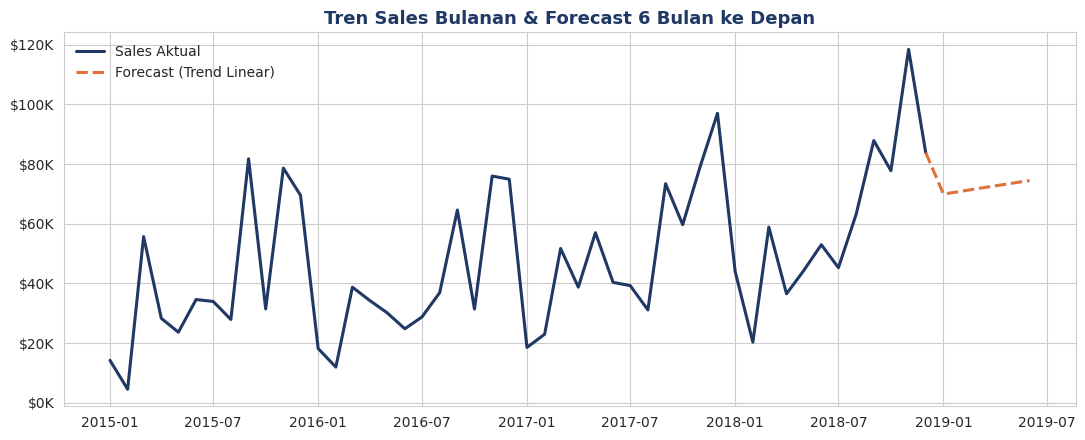

In [5]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(monthly['Order Month'], monthly['Sales'], color=NAVY, linewidth=2.2, label='Sales Aktual')
bridge_month = pd.concat([monthly['Order Month'].tail(1), forecast_df['Order Month']])
bridge_sales = pd.concat([monthly['Sales'].tail(1), forecast_df['Sales Forecast']])
ax.plot(bridge_month, bridge_sales, color=AMBER, linewidth=2.2, linestyle='--', label='Forecast (Trend Linear)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, p: f'${v/1000:.0f}K'))
ax.set_title('Tren Sales Bulanan & Forecast 6 Bulan ke Depan', fontsize=13, fontweight='bold', color=NAVY)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

## 4. Performa Kategori, Sub-Kategori & Region

Membandingkan sales dan profit margin antar kategori produk serta region penjualan.

In [6]:
cat = df.groupby('Category').agg(Sales=('Sales', 'sum'), Profit=('Profit', 'sum')).reset_index()
cat['Profit Margin'] = cat['Profit'] / cat['Sales']
cat

,Category,Sales,Profit,Profit Margin
0,Furniture,741999.7953,18451.2728,0.024867
1,Office Supplies,719047.0320,122490.8008,0.170352
2,Technology,836154.0330,145454.9481,0.173957


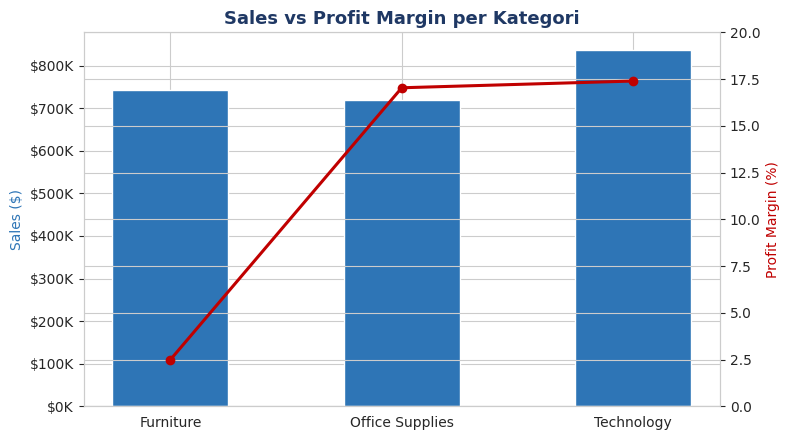

Insight: Furniture memiliki sales besar tapi margin jauh lebih tipis dibanding Technology & Office Supplies —
indikasi diskon berlebihan menggerus profit di kategori ini.


In [7]:
fig, ax1 = plt.subplots(figsize=(8, 4.5))
ax1.bar(cat['Category'], cat['Sales'], color=BLUE, width=0.5)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, p: f'${v/1000:.0f}K'))
ax1.set_ylabel('Sales ($)', color=BLUE)
ax2 = ax1.twinx()
ax2.plot(cat['Category'], cat['Profit Margin'] * 100, color=RED, marker='o', linewidth=2.2)
ax2.set_ylabel('Profit Margin (%)', color=RED)
ax2.set_ylim(0, 20)
ax1.set_title('Sales vs Profit Margin per Kategori', fontsize=13, fontweight='bold', color=NAVY)
plt.tight_layout()
plt.show()

print("Insight: Furniture memiliki sales besar tapi margin jauh lebih tipis dibanding Technology & Office Supplies —")
print("indikasi diskon berlebihan menggerus profit di kategori ini.")

In [8]:
region = df.groupby('Region').agg(Sales=('Sales', 'sum'), Profit=('Profit', 'sum')).reset_index().sort_values('Profit')
region

,Region,Sales,Profit
0,Central,501239.8908,39706.3625
2,South,391721.9050,46749.4303
1,East,678781.2400,91522.7800
3,West,725457.8245,108418.4489


## 5. Performa Produk: Top & Bottom by Profit

Mengidentifikasi produk paling menguntungkan dan produk yang justru merugi (kandidat untuk *re-pricing* atau dihentikan).

In [9]:
prod = df.groupby('Product Name').agg(Category=('Category', 'first'), Sales=('Sales', 'sum'),
                                       Profit=('Profit', 'sum'), Quantity=('Quantity', 'sum')).reset_index()
top10 = prod.sort_values('Profit', ascending=False).head(10)
bottom10 = prod.sort_values('Profit', ascending=True).head(10)

print("Top 10 Produk (Profit tertinggi):")
display(top10[['Product Name', 'Category', 'Sales', 'Profit']])
print("\nBottom 10 Produk (rugi / margin negatif):")
display(bottom10[['Product Name', 'Category', 'Sales', 'Profit']])

Top 10 Produk (Profit tertinggi):


,Product Name,Category,Sales,Profit
404,Canon imageCLASS 2200 Advanced Copier,Technology,61599.824,25199.9280
650,Fellowes PB500 Electric Punch Plastic Comb Bin...,Office Supplies,27453.384,7753.0390
805,Hewlett Packard LaserJet 3310 Copier,Technology,18839.686,6983.8836
400,Canon PC1060 Personal Laser Copier,Technology,11619.834,4570.9347
787,HP Designjet T520 Inkjet Large Format Printer ...,Technology,18374.895,4094.9766
165,Ativa V4110MDD Micro-Cut Shredder,Technology,7699.890,3772.9461
19,"3D Systems Cube Printer, 2nd Generation, Magenta",Technology,14299.890,3717.9714
1276,Plantronics Savi W720 Multi-Device Wireless He...,Technology,9367.290,3696.2820
895,Ibico EPK-21 Electric Binding System,Office Supplies,15875.916,3345.2823
1840,Zebra ZM400 Thermal Label Printer,Technology,6965.700,3343.5360



Bottom 10 Produk (rugi / margin negatif):


,Product Name,Category,Sales,Profit
475,Cubify CubeX 3D Printer Double Head Print,Technology,11099.963,-8879.9704
985,Lexmark MX611dhe Monochrome Laser Printer,Technology,16829.901,-4589.9730
476,Cubify CubeX 3D Printer Triple Head Print,Technology,7999.980,-3839.9904
425,Chromcraft Bull-Nose Wood Oval Conference Tabl...,Furniture,9917.640,-2876.1156
376,Bush Advantage Collection Racetrack Conference...,Furniture,9544.725,-1934.3976
683,GBC DocuBind P400 Electric Binding System,Office Supplies,17965.068,-1878.1662
444,Cisco TelePresence System EX90 Videoconferenci...,Technology,22638.480,-1811.0784
1043,Martin Yale Chadless Opener Electric Letter Op...,Office Supplies,16656.200,-1299.1836
285,Balt Solid Wood Round Tables,Furniture,6518.754,-1201.0581
364,BoxOffice By Design Rectangular and Half-Moon ...,Furniture,1706.250,-1148.4375


## 6. Segmentasi Pelanggan (RFM Analysis)

**RFM** mengelompokkan pelanggan berdasarkan tiga dimensi:
- **Recency** — sudah berapa lama sejak transaksi terakhir (semakin kecil semakin baik)
- **Frequency** — berapa kali mereka bertransaksi (semakin besar semakin baik)
- **Monetary** — total nilai belanja mereka (semakin besar semakin baik)

Setiap dimensi dibagi 4 kuartil (skor 1–4), lalu dikombinasikan menjadi segmen yang bisa langsung dipakai untuk strategi retensi.

In [10]:
snapshot_date = df['Order Date'].max() + pd.Timedelta(days=1)
rfm = df.groupby('Customer Name').agg(
    Recency=('Order Date', lambda x: (snapshot_date - x.max()).days),
    Frequency=('Order ID', 'nunique'),
    Monetary=('Sales', 'sum')
).reset_index()

rfm['R_Score'] = pd.qcut(rfm['Recency'], 4, labels=[4, 3, 2, 1]).astype(int)
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1, 2, 3, 4]).astype(int)
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 4, labels=[1, 2, 3, 4]).astype(int)

def segment_label(row):
    r, f, m = row['R_Score'], row['F_Score'], row['M_Score']
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3:
        return 'Loyal Customers'
    elif r <= 2 and f <= 2 and m <= 2:
        return 'At Risk / Lost'
    elif r >= 3 and f <= 2:
        return 'New / Occasional'
    else:
        return 'Needs Attention'

rfm['Segment'] = rfm.apply(segment_label, axis=1)
rfm.head()

,Customer Name,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,Segment
0,Aaron Bergman,416,3,886.156,1,1,1,At Risk / Lost
1,Aaron Hawkins,13,7,1744.700,4,3,2,Loyal Customers
2,Aaron Smayling,89,7,3050.692,2,3,3,Needs Attention
3,Adam Bellavance,55,8,7755.620,3,3,4,Loyal Customers
4,Adam Hart,35,10,3250.337,3,4,3,Loyal Customers


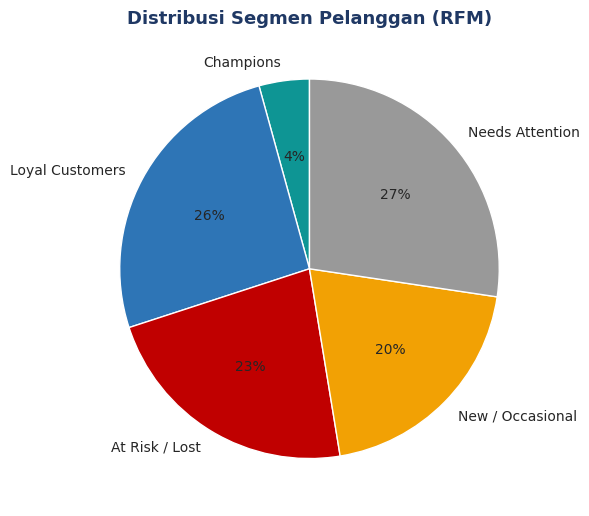

Dari 793 pelanggan, 396 (50%) berada di segmen 'At Risk' atau 'Needs Attention'.


In [11]:
seg_order = ['Champions', 'Loyal Customers', 'At Risk / Lost', 'New / Occasional', 'Needs Attention']
seg_dist = rfm['Segment'].value_counts().reindex(seg_order)
colors_map = {'Champions': TEAL, 'Loyal Customers': BLUE, 'At Risk / Lost': RED,
              'New / Occasional': '#F2A104', 'Needs Attention': '#999999'}

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(seg_dist.values, labels=seg_dist.index, autopct='%1.0f%%', startangle=90,
       colors=[colors_map[s] for s in seg_dist.index], textprops={'fontsize': 10})
ax.set_title('Distribusi Segmen Pelanggan (RFM)', fontsize=13, fontweight='bold', color=NAVY)
plt.tight_layout()
plt.show()

total_cust = len(rfm)
at_risk = seg_dist['At Risk / Lost'] + seg_dist['Needs Attention']
print(f"Dari {total_cust} pelanggan, {at_risk} ({at_risk/total_cust:.0%}) berada di segmen 'At Risk' atau 'Needs Attention'.")

In [12]:
rfm.to_csv('../data/customer_rfm_segmentation.csv', index=False)
print("Hasil segmentasi RFM disimpan ke data/customer_rfm_segmentation.csv")

Hasil segmentasi RFM disimpan ke data/customer_rfm_segmentation.csv


## 7. Kesimpulan & Rekomendasi

**Temuan utama:**
1. **Furniture adalah jebakan margin** — sales-nya besar, tapi profit margin jauh di bawah Technology & Office Supplies. Kemungkinan besar karena diskon berlebihan.
2. **Beberapa produk teknologi mahal (3D printer, printer laser tertentu) justru merugi** — kandidat kuat untuk *re-pricing* atau dihentikan.
3. **Region West & East menyumbang mayoritas profit**, sementara Central tertinggal meski sales-nya tidak kecil.
4. **Sekitar separuh basis pelanggan berada di segmen "At Risk" atau "Needs Attention"** — peluang besar untuk program retensi dibanding hanya fokus akuisisi pelanggan baru.

**Rekomendasi bisnis:**
- Batasi/tinjau ulang kebijakan diskon untuk Furniture dan region Central.
- Re-pricing atau hentikan produk yang konsisten merugi.
- Luncurkan kampanye win-back untuk pelanggan di segmen "At Risk" / "Needs Attention" sebelum menambah budget akuisisi.

Analisis lengkap dengan formula interaktif juga tersedia di `excel/Superstore_Sales_Analysis.xlsx`, dan versi dashboard visual di `dashboard/dashboard.html`.